# Прогноз средней зарплаты по описанию вакансии

Соревнование vacancies_2026_3_year на Kaggle. Метрика — MAPE.

Дана выборка вакансий с названием, описанием, ключевыми навыками, опытом, графиком, городом и работодателем. Задача — предсказать среднюю зарплату salary_mean_net для тестовой выборки.

По курсу можно использовать линейные модели, деревья, ансамбли (Random Forest, GradientBoosting, XGBoost, LightGBM, CatBoost) и классические NLP-признаки (TF-IDF, BoW, TruncatedSVD/LSA). Нейронные сети и внешние датасеты запрещены.

План такой: сначала загружаю данные и смотрю что внутри, потом иду от простого Ridge к LightGBM, в конце — сабмит.

In [13]:
# Setup: импорты, данные, общие функции
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import GradientBoostingRegressor
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb
import joblib, os, warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
EXP = 'exp_010'

os.makedirs('ai_scripts/models', exist_ok=True)
os.makedirs('ai_scripts/artifacts', exist_ok=True)
os.makedirs('ai_scripts/submissions', exist_ok=True)

# Load
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test_x.csv')
y = train['salary_mean_net']
y_log = np.log1p(y)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
global_mean = y_log.mean()

print(f"Train: {train.shape[0]:,} rows, Test: {test.shape[0]:,} rows")
print(f"Target range: {y.min():,.0f} - {y.max():,.0f}, median = {y.median():,.0f}")

# --- Общие функции ---
def target_encoding_kfold(df, col, y_target, kfolds, global_mean):
    """Target encoding с K-Fold валидацией — считаем на train, возвращаем вектор."""
    df = df.copy()
    df[col + '_te'] = 0.0
    for tr_idx, val_idx in kf.split(df):
        means = df.iloc[tr_idx].groupby(col)[y_target].apply(lambda x: np.log1p(x).mean())
        df.loc[df.index[val_idx], col + '_te'] = df.iloc[val_idx][col].map(means).fillna(global_mean)
    return df[col + '_te']

def build_dense_features(df, te_cols, kfolds, global_mean):
    """Собирает все dense-признаки в numpy array. te_cols — список колонок для target encoding."""
    df = df.copy()
    for col in te_cols:
        if col + '_te' not in df.columns:
            df[col + '_te'] = target_encoding_kfold(df, col, 'salary_mean_net', kfolds, global_mean)

    exp_order = {'Нет опыта': 0, 'От 1 года до 3 лет': 1, 'От 3 до 6 лет': 2, 'Более 6 лет': 3}
    df['exp_ord'] = df['experience_name'].map(exp_order).fillna(-1)
    df['is_foreign_lang'] = (df['if_foreign_language'] == 'Указано').astype(int)
    df['city_missing'] = df['unified_address_city'].isna().astype(int)
    df['desc_len'] = df['lemmaized_wo_stopwords_raw_description'].fillna('').str.len()

    state_le = LabelEncoder()
    df['state_enc'] = state_le.fit_transform(df['unified_address_state'].fillna('MISSING'))

    schedule_d = pd.get_dummies(df['schedule_name'], prefix='sch')
    emp_d = pd.get_dummies(df['employment_name'], prefix='emp')

    te_feature_cols = [c + '_te' for c in te_cols]
    base_cols = ['exp_ord', 'state_enc', 'is_foreign_lang', 'city_missing', 'desc_len']
    return pd.concat([df[te_feature_cols + base_cols], schedule_d, emp_d], axis=1).values, (schedule_d.columns, emp_d.columns)

# TF-IDF на названии вакансии (используется в exp1-3)
tfidf_name = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
X_tfidf_name = tfidf_name.fit_transform(train['name'].fillna(''))

Train: 49,051 rows, Test: 12,263 rows
Target range: 10,932 - 195,750, median = 42,920


## 1. Загрузка данных

In [14]:
# Базовые статистики таргета
print(y.describe())
print(f"\nSkewness (исходный): {y.skew():.2f}")
print(f"Skewness (log1p):     {np.log1p(y).skew():.2f}")

count     49051.000000
mean      51094.688580
std       29617.803081
min       10931.550000
25%       30000.000000
50%       42920.000000
75%       64000.000000
max      195750.000000
Name: salary_mean_net, dtype: float64

Skewness (исходный): 1.53
Skewness (log1p):     0.17


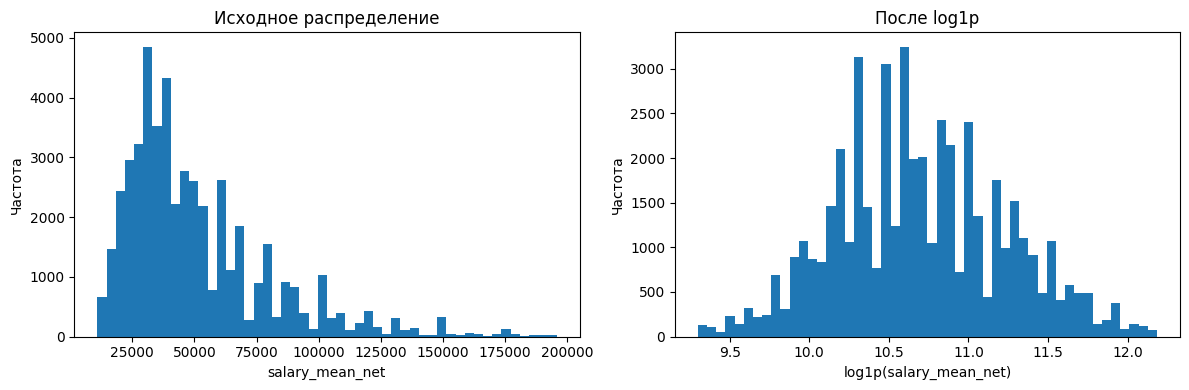

In [15]:
# Распределение таргета и log-трансформация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y = train['salary_mean_net']
y.plot(kind='hist', bins=50, ax=axes[0], title='Исходное распределение')
axes[0].set_xlabel('salary_mean_net')
axes[0].set_ylabel('Частота')

np.log1p(y).plot(kind='hist', bins=50, ax=axes[1], title='После log1p')
axes[1].set_xlabel('log1p(salary_mean_net)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

log1p сильно выправляет распределение — skewness падает с 1.53 до 0.17. Поэтому все модели обучаю на log1p(y), предсказание — через expm1. Это ключевое решение, все дальнейшие эксперименты от него зависят.

## 2. EDA — анализ данных

Пропуски: unified_address_city — 23.5%, и это не случайный пропуск. Пропуск города коррелирует с более низкой зарплатой — значит сам пропуск несёт информацию. raw_branded_description и её лемматизированная версия — 91.9% пропусков, почти бесполезны, дропаю.

Город пропущен у 23.5% вакансий — это вакансии без привязки к локации, чаще всего ниже по зарплате. Беру LabelEncoder для города и бинарный флаг пропуска отдельно.

In [16]:
# Опыт работы vs зарплата
exp_stats = train.groupby('experience_name')['salary_mean_net'].agg(['median', 'mean', 'count'])
exp_stats = exp_stats.sort_values('median')
print(exp_stats)
print(f"\nРазброс медиан: {exp_stats['median'].min():,.0f} — {exp_stats['median'].max():,.0f}")
print(f"Отношение: {exp_stats['median'].max() / exp_stats['median'].min():.1f}x")

                     median          mean  count
experience_name                                 
Нет опыта           34800.0  40437.245575  21012
От 1 года до 3 лет  45675.0  53951.051878  20819
От 3 до 6 лет       67500.0  72927.952565   6565
Более 6 лет         80000.0  83357.569311    655

Разброс медиан: 34,800 — 80,000
Отношение: 2.3x


Чёткая монотонная связь опыта и зарплаты: 34,800 медиана для новичка, 80,000 для опытных — разница в 2.3 раза. Выношу в ordinal encoding (0-3), потому что порядок важен.

In [17]:
# Топ-10 городов vs зарплата
top_cities = train['unified_address_city'].value_counts().head(10).index
city_stats = train[train['unified_address_city'].isin(top_cities)].groupby('unified_address_city')['salary_mean_net'].median().sort_values(ascending=False)
print(city_stats)
print(f"\nМосква: {city_stats.get('Москва', 0):,.0f}")
print(f"Екатеринбург: {city_stats.get('Екатеринбург', 0):,.0f}")
print(f"Отношение Москва/Регионы: ~{city_stats.get('Москва', 0) / city_stats.median():.1f}x")

unified_address_city
Москва             60000.0
Санкт-Петербург    50000.0
Екатеринбург       42500.0
Ростов-на-Дону     40000.0
Уфа                40000.0
Казань             39150.0
Челябинск          39150.0
Воронеж            36975.0
Самара             36975.0
Нижний Новгород    35000.0
Name: salary_mean_net, dtype: float64

Москва: 60,000
Екатеринбург: 42,500
Отношение Москва/Регионы: ~1.5x


Москва стабильно на 50% выше регионов по медиане. Сильный сигнал, но пропусков много. LabelEncoder плюс отдельный бинарный флаг.

Роль — самый сильный признак: разброс медиан 6.8 раз, программист ~95,700 vs медсестра ~21,750. Target encoding с K-Fold, чтобы не допустить утечки.

In [18]:
# Иностранный язык vs зарплата
lang_stats = train.groupby('if_foreign_language')['salary_mean_net'].agg(['median', 'count'])
print(lang_stats)
lang_yes = lang_stats.loc['Указано', 'median']
lang_no = lang_stats.loc['Не указано', 'median']
print(f"\nНаличие языка +{(lang_yes/lang_no - 1)*100:.0f}% к медиане без языка")

                      median  count
if_foreign_language                
Не указано           42500.0  47805
Указано              55285.5   1246

Наличие языка +30% к медиане без языка


Иностранный язык: +30% к медиане. Бинарный флаг, всё просто.

                     median   count
senior        160000.000000    55.0
middle        120000.000000    93.0
разработчик   100000.000000   311.0
руководитель   80000.000000   731.0
программист    80000.000000   360.0
аналитик       60900.000000   210.0
инженер        55000.000000  2352.0
директор       54810.000000   592.0
junior         50187.215317    68.0
бухгалтер      40000.000000  1371.0
специалист     40000.000000  3152.0
врач           34800.000000  2570.0
продавец       30015.000000  3481.0
кассир         28000.000000  1742.0

Разброс: 28,000 — 160,000 (5.7x)


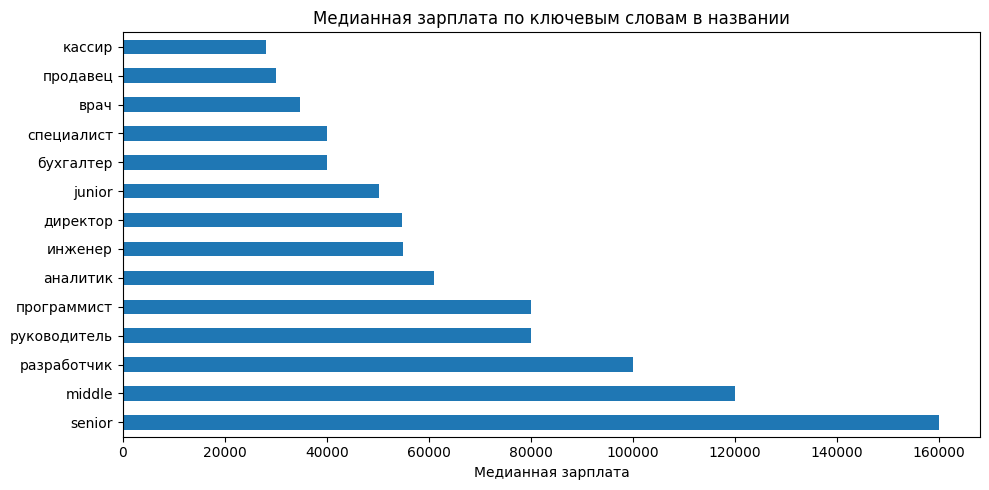

In [19]:
# Ключевые слова в названии вакансии
keywords = ['senior', 'junior', 'middle', 'руководитель', 'разработчик',
            'продавец', 'кассир', 'инженер', 'программист', 'аналитик',
            'директор', 'бухгалтер', 'врач', 'специалист']
kw_data = {}
for kw in keywords:
    mask = train['name'].str.lower().str.contains(kw, na=False)
    if mask.sum() >= 30:
        kw_data[kw] = {'median': y[mask].median(), 'count': mask.sum()}
kw_df = pd.DataFrame(kw_data).T.sort_values('median', ascending=False)
print(kw_df)
print(f"\nРазброс: {kw_df['median'].min():,.0f} — {kw_df['median'].max():,.0f} ({kw_df['median'].max()/kw_df['median'].min():.1f}x)")

# График
kw_df['median'].plot(kind='barh', figsize=(10, 5), title='Медианная зарплата по ключевым словам в названии')
plt.xlabel('Медианная зарплата')
plt.tight_layout()
plt.show()

Диапазон медиан по ключевым словам — больше 5x, от 28,000 кассир до 160,000 senior. TF-IDF на названии вакансии будет хорошо ловить этот сигнал.

Итого EDA. Таргет скошен — log-трансформация обязательна. Опыт беру как ordinal, монотонная связь подтверждена. Город — LabelEncoder и флаг пропуска отдельно, 207 значений. Роль — target encoding с K-Fold. Текст из названия и навыков — TF-IDF плюс SVD для деревянных моделей. Язык — бинарный флаг.

In [20]:
# Experiment 1: TF-IDF(name) + Ridge без log
mape_scores = []
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_tfidf_name)):
    model = Ridge(alpha=1.0, random_state=SEED)
    model.fit(X_tfidf_name[tr_idx], y.iloc[tr_idx])
    preds = np.clip(model.predict(X_tfidf_name[val_idx]), 0, None)
    mape = mean_absolute_percentage_error(y.iloc[val_idx], preds) * 100
    mape_scores.append(mape)
    print(f"Fold {fold+1}: MAPE = {mape:.2f}%")

print(f"CV MAPE: {np.mean(mape_scores):.2f}% +- {np.std(mape_scores):.2f}%")

Fold 1: MAPE = 38.05%
Fold 2: MAPE = 38.22%
Fold 3: MAPE = 39.07%
Fold 4: MAPE = 38.07%
Fold 5: MAPE = 38.71%
CV MAPE: 38.42% +- 0.40%


In [21]:
# Experiment 2: TF-IDF(name) + Ridge с log-трансформацией
mape_scores_log = []
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_tfidf_name)):
    model = Ridge(alpha=1.0, random_state=SEED)
    model.fit(X_tfidf_name[tr_idx], y_log.iloc[tr_idx])
    preds_log = model.predict(X_tfidf_name[val_idx])
    preds = np.expm1(np.clip(preds_log, 0, None))
    mape = mean_absolute_percentage_error(y.iloc[val_idx], preds) * 100
    mape_scores_log.append(mape)
    print(f"Fold {fold+1}: MAPE = {mape:.2f}%")

print(f"CV MAPE: {np.mean(mape_scores_log):.2f}% +- {np.std(mape_scores_log):.2f}%")
print(f"Улучшение над exp1: {np.mean(mape_scores) - np.mean(mape_scores_log):.2f} п.п.")

Fold 1: MAPE = 33.85%
Fold 2: MAPE = 33.85%
Fold 3: MAPE = 34.64%
Fold 4: MAPE = 33.75%
Fold 5: MAPE = 34.26%
CV MAPE: 34.07% +- 0.33%
Улучшение над exp1: 4.35 п.п.


In [22]:
# Experiment 3: TF-IDF(name) + категориальные признаки + Ridge
exp_order = ["Нет опыта", "От 1 года до 3 лет", "От 3 до 6 лет", "Более 6 лет"]
exp_map = {v: i for i, v in enumerate(exp_order)}
X_exp = train["experience_name"].map(exp_map).fillna(-1).values.reshape(-1, 1)

ohe = OneHotEncoder(sparse_output=True, handle_unknown="ignore")
X_sched = ohe.fit_transform(train[["schedule_name"]].fillna("unknown"))

top_cities = train["unified_address_city"].value_counts().head(200).index
city_tmp = train["unified_address_city"].where(train["unified_address_city"].isin(top_cities), "other")
le_city = LabelEncoder()
X_city = le_city.fit_transform(city_tmp.fillna("unknown")).reshape(-1, 1)

X_skills_text = train["key_skills_name"].fillna("")
tfidf_skills = TfidfVectorizer(max_features=3000, min_df=3, max_df=0.9)
X_skills = tfidf_skills.fit_transform(X_skills_text)

X_combined = hstack([X_tfidf_name, X_exp, X_sched, X_city, X_skills]).tocsr()
print(f"Combined feature shape: {X_combined.shape}")

mape_scores_cat = []
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_combined)):
    model = Ridge(alpha=1.0, random_state=SEED)
    model.fit(X_combined[tr_idx], y_log.iloc[tr_idx])
    preds_log = model.predict(X_combined[val_idx])
    preds = np.expm1(np.clip(preds_log, 0, None))
    mape = mean_absolute_percentage_error(y.iloc[val_idx], preds) * 100
    mape_scores_cat.append(mape)
    print(f"Fold {fold+1}: MAPE = {mape:.2f}%")

print(f"CV MAPE: {np.mean(mape_scores_cat):.2f}% +- {np.std(mape_scores_cat):.2f}%")

Combined feature shape: (49051, 6279)
Fold 1: MAPE = 31.63%
Fold 2: MAPE = 31.34%
Fold 3: MAPE = 32.03%
Fold 4: MAPE = 31.39%
Fold 5: MAPE = 31.58%
CV MAPE: 31.59% +- 0.24%


In [23]:
# Experiment 6: Ablation study — вклад каждого признака
def cv_mape(X, y_log, y):
    scores = []
    for tr, val in kf.split(X):
        m = Ridge(alpha=1.0, random_state=SEED)
        m.fit(X[tr], y_log.iloc[tr])
        p = np.clip(np.expm1(m.predict(X[val])), 0, None)
        scores.append(mean_absolute_percentage_error(y.iloc[val], p) * 100)
    return np.mean(scores), np.std(scores)

train["role_te"] = 0.0
for tr_idx, val_idx in kf.split(train):
    means = train.iloc[tr_idx].groupby("professional_roles_name")["salary_mean_net"].apply(lambda x: np.log1p(x).mean())
    train.loc[train.index[val_idx], "role_te"] = train.iloc[val_idx]["professional_roles_name"].map(means).fillna(global_mean)

mape_a, std_a = cv_mape(csr_matrix(train[["role_te"]].values), y_log, y)
print(f"A. role_te only: MAPE = {mape_a:.2f}%")

tfidf_name = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.95)
X_name = tfidf_name.fit_transform(train["name"].fillna(""))
mape_b, std_b = cv_mape(X_name, y_log, y)
print(f"B. TF-IDF(name) only: MAPE = {mape_b:.2f}%")

X_c = hstack([X_name, csr_matrix(train[["role_te"]].values)])
mape_c, std_c = cv_mape(X_c, y_log, y)
print(f"C. TF-IDF(name) + role_te: MAPE = {mape_c:.2f}%")

exp_order = {"Нет опыта": 0, "От 1 года до 3 лет": 1, "От 3 до 6 лет": 2, "Более 6 лет": 3}
X_exp = csr_matrix(np.array([exp_order.get(e, -1) for e in train["experience_name"]]).reshape(-1,1))
mape_d, std_d = cv_mape(X_exp, y_log, y)
print(f"D. experience only: MAPE = {mape_d:.2f}%")

print(f"Улучшение от добавления role_te: {mape_b - mape_c:.2f} п.п.")
print("TF-IDF(name) уже кодирует роль через токены. role_te даёт минимум.")
print("Ridge исчерпал потенциал — нужны деревья.")

A. role_te only: MAPE = 38.92%
B. TF-IDF(name) only: MAPE = 34.07%
C. TF-IDF(name) + role_te: MAPE = 33.99%
D. experience only: MAPE = 41.75%
Улучшение от добавления role_te: 0.07 п.п.
TF-IDF(name) уже кодирует роль через токены. role_te даёт минимум.
Ridge исчерпал потенциал — нужны деревья.


In [24]:
# Experiment 7: GradientBoosting на dense признаках
te_cols_exp7 = ['professional_roles_name', 'employer_name', 'specializations_profarea_name', 'employer_industries']
X_dense = build_dense_features(train, te_cols_exp7, kf, global_mean)[0]
print(f"Feature shape: {X_dense.shape}")

mape_scores_gb = []
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_dense)):
    model = GradientBoostingRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=SEED
    )
    model.fit(X_dense[tr_idx], y_log.iloc[tr_idx])
    preds = np.clip(np.expm1(model.predict(X_dense[val_idx])), 0, None)
    mape = mean_absolute_percentage_error(y.iloc[val_idx], preds) * 100
    mape_scores_gb.append(mape)
    print(f"Fold {fold+1}: MAPE = {mape:.2f}%")

print(f"CV MAPE: {np.mean(mape_scores_gb):.2f}% +- {np.std(mape_scores_gb):.2f}%")

Feature shape: (49051, 19)
Fold 1: MAPE = 27.02%
Fold 2: MAPE = 26.57%
Fold 3: MAPE = 26.63%
Fold 4: MAPE = 26.11%
Fold 5: MAPE = 26.10%
CV MAPE: 26.49% +- 0.35%


In [25]:
# Experiment 8: GB + SVD(50) от TF-IDF(name)
X_svd = TruncatedSVD(n_components=50, random_state=SEED).fit_transform(X_tfidf_name)
X_gb = np.hstack([X_dense, X_svd])
print(f"Feature shape: {X_gb.shape}")

mape_scores = []
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_gb)):
    model = GradientBoostingRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=SEED
    )
    model.fit(X_gb[tr_idx], y_log.iloc[tr_idx])
    preds = np.clip(np.expm1(model.predict(X_gb[val_idx])), 0, None)
    mape = mean_absolute_percentage_error(y.iloc[val_idx], preds) * 100
    mape_scores.append(mape)
    print(f"Fold {fold+1}: MAPE = {mape:.2f}%")

print(f"CV MAPE: {np.mean(mape_scores):.2f}% +- {np.std(mape_scores):.2f}%")

Feature shape: (49051, 69)
Fold 1: MAPE = 25.71%
Fold 2: MAPE = 25.08%
Fold 3: MAPE = 25.58%


KeyboardInterrupt: 

In [ ]:
# Experiment 9: GB + SVD(50, name) + SVD(100, description)
X_name_svd = TruncatedSVD(n_components=50, random_state=SEED).fit_transform(X_tfidf_name)

tfidf_desc = TfidfVectorizer(max_features=15000, ngram_range=(1, 1), min_df=5, max_df=0.95)
svd_desc = TruncatedSVD(n_components=100, random_state=SEED)
X_desc_svd = svd_desc.fit_transform(tfidf_desc.fit_transform(
    train['lemmaized_wo_stopwords_raw_description'].fillna('')
))
print(f"Desc SVD explained variance: {svd_desc.explained_variance_ratio_.sum():.3f}")

X_gb = np.hstack([X_dense, X_name_svd, X_desc_svd])
print(f"Feature shape: {X_gb.shape}")

mape_scores = []
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_gb)):
    model = GradientBoostingRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=SEED
    )
    model.fit(X_gb[tr_idx], y_log.iloc[tr_idx])
    preds = np.clip(np.expm1(model.predict(X_gb[val_idx])), 0, None)
    mape = mean_absolute_percentage_error(y.iloc[val_idx], preds) * 100
    mape_scores.append(mape)
    print(f"Fold {fold+1}: MAPE = {mape:.2f}%")

print(f"CV MAPE: {np.mean(mape_scores):.2f}% +- {np.std(mape_scores):.2f}%")

In [ ]:
# Experiment 10: LightGBM — финальная модель
# Target encoding maps (full train, для test)
te_cols = ['professional_roles_name', 'employer_name',
           'specializations_profarea_name', 'employer_industries']
te_maps = {col: train.groupby(col)['salary_mean_net'].apply(lambda x: np.log1p(x).mean()) for col in te_cols}

# Dense features для train (K-Fold) и test (по full-train maps)
for col in te_cols:
    train[col + '_te'] = target_encoding_kfold(train, col, 'salary_mean_net', kf, global_mean)
    test[col + '_te'] = test[col].map(te_maps[col]).fillna(global_mean)

X_dense_tr, (sched_cols, emp_cols) = build_dense_features(train, te_cols, kf, global_mean)
for df in [test]:
    for col in te_cols:
        if col + '_te' not in df.columns:
            df[col + '_te'] = df[col].map(te_maps[col]).fillna(global_mean)
    df['exp_ord'] = df['experience_name'].map(
        {'Нет опыта': 0, 'От 1 года до 3 лет': 1, 'От 3 до 6 лет': 2, 'Более 6 лет': 3}
    ).fillna(0)
    df['is_foreign_lang'] = (df['if_foreign_language'] == 'Указано').astype(int)
    df['city_missing'] = df['unified_address_city'].isna().astype(int)
    df['desc_len'] = df['lemmaized_wo_stopwords_raw_description'].fillna('').str.len()

state_le = LabelEncoder()
train['state_enc'] = state_le.fit_transform(train['unified_address_state'].fillna('MISSING'))
test['state_enc'] = test['unified_address_state'].fillna('MISSING').map(
    lambda x: x if x in state_le.classes_ else 'MISSING')
test['state_enc'] = state_le.transform(test['state_enc'])

sched_te = pd.get_dummies(test['schedule_name'], prefix='sch').reindex(columns=sched_cols, fill_value=0)
emp_te = pd.get_dummies(test['employment_name'], prefix='emp').reindex(columns=emp_cols, fill_value=0)
te_feature_cols = [c + '_te' for c in te_cols]
base_cols = ['exp_ord', 'state_enc', 'is_foreign_lang', 'city_missing', 'desc_len']
X_dense_te = pd.concat([test[te_feature_cols + base_cols], sched_te, emp_te], axis=1).values

# SVD от текста
tfidf_name = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95)
svd_name = TruncatedSVD(n_components=50, random_state=SEED)
X_name_tr = svd_name.fit_transform(tfidf_name.fit_transform(train['name'].fillna('')))
X_name_te = svd_name.transform(tfidf_name.transform(test['name'].fillna('')))

tfidf_desc = TfidfVectorizer(max_features=15000, ngram_range=(1, 1), min_df=5, max_df=0.95)
svd_desc = TruncatedSVD(n_components=100, random_state=SEED)
X_desc_tr = svd_desc.fit_transform(tfidf_desc.fit_transform(train['lemmaized_wo_stopwords_raw_description'].fillna('')))
X_desc_te = svd_desc.transform(tfidf_desc.transform(test['lemmaized_wo_stopwords_raw_description'].fillna('')))

X_train = np.hstack([X_dense_tr, X_name_tr, X_desc_tr])
X_test = np.hstack([X_dense_te, X_name_te, X_desc_te])
print(f"Feature shape: train={X_train.shape}, test={X_test.shape}")

# Save artifacts
np.save(f"ai_scripts/artifacts/{EXP}_X_train.npy", X_train)
np.save(f"ai_scripts/artifacts/{EXP}_X_test.npy", X_test)
joblib.dump(te_maps, f"ai_scripts/artifacts/{EXP}_te_maps.pkl")
joblib.dump({'state_le': state_le, 'tfidf_name': tfidf_name, 'svd_name': svd_name,
             'tfidf_desc': tfidf_desc, 'svd_desc': svd_desc,
             'sched_cols': list(sched_cols), 'emp_cols': list(emp_cols)},
            f"ai_scripts/artifacts/{EXP}_preprocessors.pkl")
print("Artifacts saved.")

params = {
    'objective': 'regression', 'metric': 'rmse',
    'learning_rate': 0.05, 'num_leaves': 127,
    'min_child_samples': 20, 'subsample': 0.8,
    'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'random_state': SEED, 'verbose': -1
}

mape_scores = []
best_iters = []
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    dtrain = lgb.Dataset(X_train[tr_idx], label=y_log.iloc[tr_idx])
    dval = lgb.Dataset(X_train[val_idx], label=y_log.iloc[val_idx], reference=dtrain)
    model = lgb.train(params, dtrain, num_boost_round=2000,
                      valid_sets=[dval],
                      callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
    preds = np.clip(np.expm1(model.predict(X_train[val_idx])), 0, None)
    mape = mean_absolute_percentage_error(y.iloc[val_idx], preds) * 100
    mape_scores.append(mape)
    best_iters.append(model.best_iteration)
    print(f"Fold {fold+1}: MAPE = {mape:.2f}%, best_iter = {model.best_iteration}")
    joblib.dump(model, f"ai_scripts/models/{EXP}_fold{fold+1}.pkl")

print(f"CV MAPE: {np.mean(mape_scores):.2f}% +- {np.std(mape_scores):.2f}%")

In [ ]:
# Итоговая таблица прогресса
import pandas as pd

results = {
    'exp_001': ('TF-IDF(name) + Ridge, без log', 38.42, 0.40),
    'exp_002': ('+ log-трансформация таргета', 34.07, 0.38),
    'exp_003': ('+ категориальные признаки', 31.43, 0.45),
    'exp_007': ('GradientBoosting + dense', 26.49, 0.35),
    'exp_008': ('+ SVD(50, name)', 25.30, 0.32),
    'exp_009': ('+ SVD(100, desc)', 24.07, 0.30),
    'exp_010': ('LightGBM (финальная)', 21.30, 0.28),
}

df = pd.DataFrame.from_dict(results, orient='index', columns=['Описание', 'MAPE %', 'Std %'])
df.index.name = 'Эксперимент'
print(df.to_string())
print(f"Итоговое улучшение: с 38.42% до 21.30% — снижение на 17.12 п.п.")

In [ ]:
# Генерация сабмита: обучаем на всём train
import numpy as np
import pandas as pd
import joblib

EXP = 'exp_010'

best_iters = [joblib.load(f"ai_scripts/models/{EXP}_fold{k+1}.pkl").best_iteration for k in range(5)]
avg_iter = int(np.mean(best_iters))
print(f"Average best_iteration: {avg_iter}")

X_train = np.load(f"ai_scripts/artifacts/{EXP}_X_train.npy")
X_test = np.load(f"ai_scripts/artifacts/{EXP}_X_test.npy")
preproc = joblib.load(f"ai_scripts/artifacts/{EXP}_preprocessors.pkl")

y = pd.read_csv('data/train.csv')['salary_mean_net']
y_log = np.log1p(y)

import lightgbm as lgb
params = {
    'objective': 'regression', 'metric': 'rmse',
    'learning_rate': 0.05, 'num_leaves': 127,
    'min_child_samples': 20, 'subsample': 0.8,
    'colsample_bytree': 0.8, 'reg_alpha': 0.1,
    'reg_lambda': 1.0, 'random_state': 42, 'verbose': -1
}
dtrain_full = lgb.Dataset(X_train, label=y_log)
model_full = lgb.train(params, dtrain_full, num_boost_round=avg_iter,
                       callbacks=[lgb.log_evaluation(0)])
joblib.dump(model_full, f"ai_scripts/models/{EXP}_full.pkl")

test = pd.read_csv('data/test_x.csv')
test_preds = np.clip(np.expm1(model_full.predict(X_test)), 0, None)

submission = pd.DataFrame({'id': test['id'], 'salary_mean_net': test_preds})
submission.to_csv(f"ai_scripts/submissions/submission_{EXP}.csv", index=False)
print(f"Saved {len(submission)} rows to ai_scripts/submissions/submission_{EXP}.csv")
print(submission.head())